In [37]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
import gzip
%matplotlib widget

In [38]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe()

In [39]:
# hppc_data_raw = pd.read_csv('./data/hppc/' + 'GMJuly2022_CELL017_RPT_1_P25C_25P0PSI_20221121_R0_CH040_20221121171209_37_1_8_2818580181_HPPC' + '.csv')
# hppc_data = hppc_data_raw
# hppc_data_raw.head()


# hppc_data_raw = pd.read_csv('./data/hppc/' + 'GMJuly2022_CELL017_RPT_1_P25C_25P0PSI_20221121_R0_CH040_20221121171209_37_1_8_2818580181_HPPC' + '.csv')
file_path='V:\\voltaiq_data\\Processed\\GMJuly2022\\GMJuly2022_CELL081\\RPT.pkl.gz'

with gzip.open(file_path, "rb") as f:
    hppc_data_raw = pickle.load(f)




<class 'pandas.core.frame.DataFrame'>
Index: 62799 entries, 14227606 to 14290404
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Time [s]             62799 non-null  float64
 1   Current [A]          62799 non-null  float64
 2   Voltage [V]          62799 non-null  float64
 3   Ah throughput [A.h]  62799 non-null  float64
 4   Temperature [degC]   62799 non-null  float64
 5   Step index           62799 non-null  float64
dtypes: float64(6)
memory usage: 3.4 MB


<Axes: xlabel='Time [s]'>

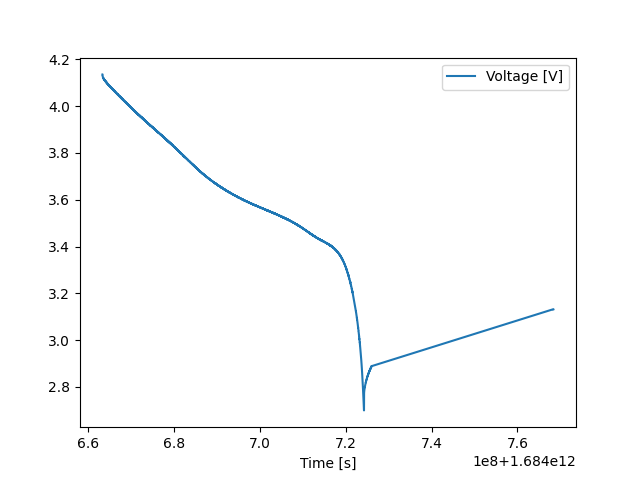

In [40]:
#display(hppc_data_raw["Data"])
hppc_data_pulse = hppc_data_raw.iloc[1].Data #HPPC
hppc_data_charge = hppc_data_raw.iloc[2].Data #C/20 Discharge
hppc_data_discharge = hppc_data_raw.iloc[3].Data #C/20 Discharge
hppc_data=hppc_data_discharge
# pd.concat
# pandas merge
#hppc_data.head()
#hppc_data["Time [s]"]
hppc_data.info(show_counts=True, memory_usage=True, verbose=True)
hppc_data.plot(x="Time [s]",y="Voltage [V]")

#hppc_data.plot(x="Time [s]",y="Ah throughput [A.h]")

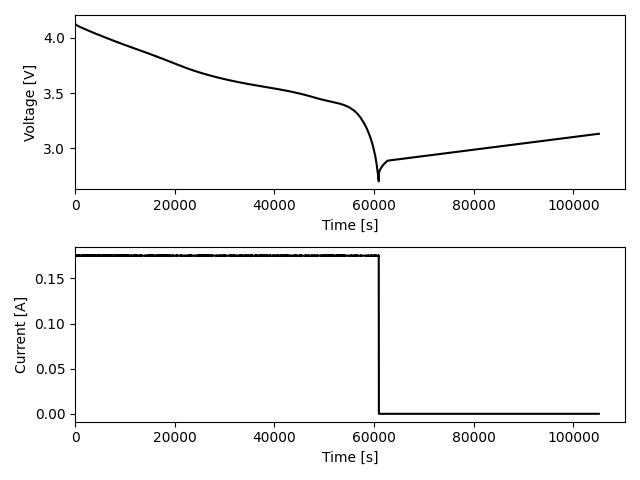

In [41]:
# hppc_data['Time [s]'] = hppc_data_raw['Time [s]'].str.replace(r'-05:00', '', regex=True)
#hppc_data['Time [s]'] = pd.to_datetime(hppc_data['Time [s]'] , format='%Y-%m-%d %H:%M:%S-%f:00')
data_time = hppc_data["Time [s]"].to_numpy()/1000# convert from unix time in ms?-hppc_data.iloc(0)["Time [s]"]
data_time=data_time-data_time[0]
# #data_time = data_time.values/1e9
# #data_time = data_time.astype('float')
data_current = hppc_data['Current [A]'].to_numpy()
# #data_current = data_current.values
#t_sim = np.arange(0,data_time[-1],0.1)
t_sim = np.arange(0,data_time[-1],10)

data_current = np.interp(t_sim, data_time, data_current, left=None, right=None, period=None)
data_voltage= hppc_data['Voltage [V]'].to_numpy()
# #data_voltage = data_voltage.values
data_voltage = np.interp(t_sim, data_time, data_voltage, left=None, right=None, period=None)

fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t_sim,data_voltage,'k')
#ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,-data_current,'k')
#ax2.plot(t,I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()


In [42]:
timescale = parameter_values.evaluate(spme.timescale)
# discharge is positive current in PyBaMM
current_interpolant = pybamm.Interpolant(
  #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
  t_sim, -data_current, timescale * pybamm.t
)
parameter_values["Current function [A]"] = current_interpolant

In [60]:
spme = pybamm.lithium_ion.SPMe()
param = spme.param
parameter_values.update(
    {
        "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
        "Maximum concentration in negative electrode [mol.m-3]":	29637,
        "Upper voltage cut-off [V]": 4.2 
        },
    check_already_exists=False,
)    
parameter_values.search("maximum concentration")
parameter_values.search("voltage")
# Cn
C_n_init = 4.8 
# Cp
C_p_init = 4.728
# x0 or x100 depending on starting at 0 SOC or 1 SOC
x_init = 0.834
# y0 or y100 depending on starting at 0 SOC or 1 SOC
y_init = 0.305
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))

# x100=x_init
# x0=
# y100=y_init
# y0=
# C_p_usable=parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
# C_n_usable=

#eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
#eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))

cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)



# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
    },
    check_already_exists=False,
)

Vmin = 2.7
Vmax = 4.2
esoh_model = pybamm.lithium_ion.ElectrodeSOH()
esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
esoh_solver = pybamm.lithium_ion.ElectrodeSOHSolver(parameter_values, param)
Cn = parameter_values.evaluate(param.n.cap_init)
Cp = parameter_values.evaluate(param.p.cap_init)
eps_n = parameter_values["Negative electrode active material volume fraction"]
eps_p = parameter_values["Positive electrode active material volume fraction"]
c_n_max = parameter_values.evaluate(param.n.prim.c_max)
c_p_max = parameter_values.evaluate(param.p.prim.c_max)
n_Li_init = parameter_values.evaluate(param.n_Li_particles_init)

esoh_sol = esoh_sim.solve(
    [0],
    inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
    solver=pybamm.AlgebraicSolver(),
)

x100=esoh_sol["x_100"].data[0]
y100=esoh_sol["y_100"].data[0]
x0=esoh_sol["x_0"].data[0]
y0=esoh_sol["y_0"].data[0]
print(x100)
print(y100)
print(x0)
print(y0)

Maximum concentration in negative electrode [mol.m-3]	29637
Maximum concentration in positive electrode [mol.m-3]	31927.3
Lower voltage cut-off [V]	2.8
Upper voltage cut-off [V]	4.2
0.8337500300451361
0.30525377660392256
0.1511161105918096
0.9982831364550155


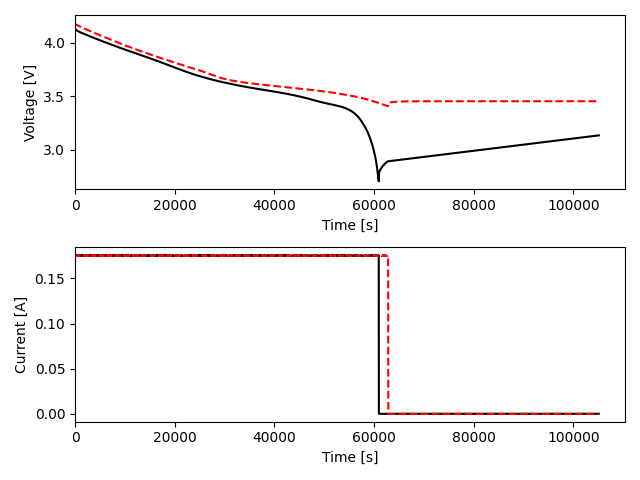

In [61]:
sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(t_eval=t_sim) #,initial_soc =0.99

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t_sim,data_voltage,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,-data_current,'k')
ax2.plot(t,I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()